In [5]:
# CELDA 1: Importaciones y Configuración de Rutas
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# Estilo de graficas para el TFG
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Configuración de rutas (Notebook en /notebooks, código en /src)
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"

# Anadimos /src al sistema para poder importar tus modulos
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# Rutas a los archivos generados por el entrenamiento (asumiendo que se guardaron en /src)
HISTORY_PATH = SRC_DIR / "history_panns.csv"
MODEL_PATH = SRC_DIR / "best_panns_model.pth"

print(f"Raiz del proyecto detectada: {PROJECT_ROOT}")
print("Entorno configurado correctamente. Listo para importar modulos de src.")

Raiz del proyecto detectada: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones
Entorno configurado correctamente. Listo para importar modulos de src.


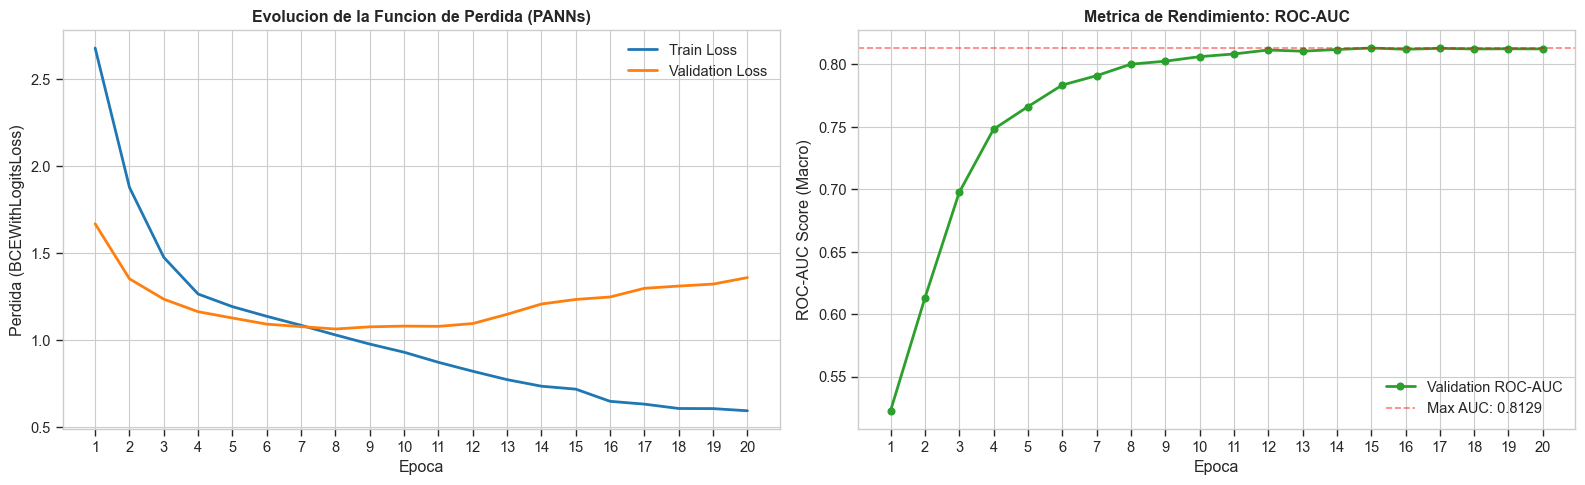

In [2]:
# CELDA 2: Visualizacion del Historial de Entrenamiento
df_history = pd.read_csv(HISTORY_PATH)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Grafica 1: Evolucion de la Perdida (Loss)
ax1.plot(df_history['epoch'], df_history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(df_history['epoch'], df_history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Evolucion de la Funcion de Perdida (PANNs)', fontweight='bold')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Perdida (BCEWithLogitsLoss)')
ax1.legend()
ax1.set_xticks(df_history['epoch'])

# Grafica 2: Evolucion del ROC-AUC
ax2.plot(df_history['epoch'], df_history['val_auc'], label='Validation ROC-AUC', color='#2ca02c', linewidth=2, marker='o')
ax2.axhline(y=df_history['val_auc'].max(), color='r', linestyle='--', alpha=0.5, 
            label=f'Max AUC: {df_history["val_auc"].max():.4f}')
ax2.set_title('Metrica de Rendimiento: ROC-AUC', fontweight='bold')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('ROC-AUC Score (Macro)')
ax2.legend()
ax2.set_xticks(df_history['epoch'])

plt.tight_layout()
plt.savefig("panns_learning_curves.png", dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
# CELDA 3: Carga del Modelo y Preparacion de Datos de Validacion
from dataset import MTGJamendoDataset
from audio_utils import AudioPreprocessor
from models_panns import build_panns_model
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TSV_PATH = PROJECT_ROOT / "mtg-jamendo-dataset" / "data" / "autotagging_moodtheme.tsv"
AUDIO_DIR = PROJECT_ROOT / "data" / "audio"

# 1. Recuperar las etiquetas
registros = []
with open(TSV_PATH, 'r', encoding='utf-8') as f:
    next(f)
    for linea in f:
        if not linea.strip(): continue
        parts = linea.strip().split('\t')
        if len(parts) >= 6:
            tags = [t.replace('mood/theme---', '').strip() for t in parts[5:] if t.startswith('mood/theme---')]
            if tags: registros.append({'path': parts[3], 'tags': tags})

df_all = pd.DataFrame(registros)
etiquetas_jamendo = sorted(list(set(tag for tags in df_all['tags'] for tag in tags if tag.strip())))

# 2. Recrear SOLO el conjunto de validacion
df_train = df_all.sample(frac=0.8, random_state=42)
df_val = df_all.drop(df_train.index)

preprocesador = AudioPreprocessor(target_sr=32000)
val_ds = MTGJamendoDataset(df_val, AUDIO_DIR, preprocesador, etiquetas_jamendo, return_raw=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=4)

# 3. Cargar el modelo con los mejores pesos
model = build_panns_model(num_classes=59, device=DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print(f"Modelo cargado correctamente. Evaluando {len(df_val)} audios...")

# 4. Extraer predicciones
all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in tqdm(val_loader, desc="Inferencia de Validacion"):
        x = x.to(DEVICE)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(x)
        all_preds.append(torch.sigmoid(logits).cpu().float().numpy())
        all_targets.append(y.numpy())

y_true = np.vstack(all_targets)
y_score = np.vstack(all_preds)
print("Inferencia completada.")

Construyendo arquitectura CNN14 de PANNs...
Inyectando pesos pre-entrenados en la red...
Transfer Learning completado. El modelo está listo para el Fine-Tuning con MTG-Jamendo.
Modelo cargado correctamente. Evaluando 3697 audios...


Inferencia de Validacion: 100%|██████████| 232/232 [10:08<00:00,  2.62s/it]

Inferencia completada.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_19924\716769807.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_auc.head(10), x='ROC-AUC', y='Etiqueta', ax=ax1, palette='Greens_r')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_19924\716769807.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_auc.tail(10).sort_values(by='ROC-AUC', ascending=True),


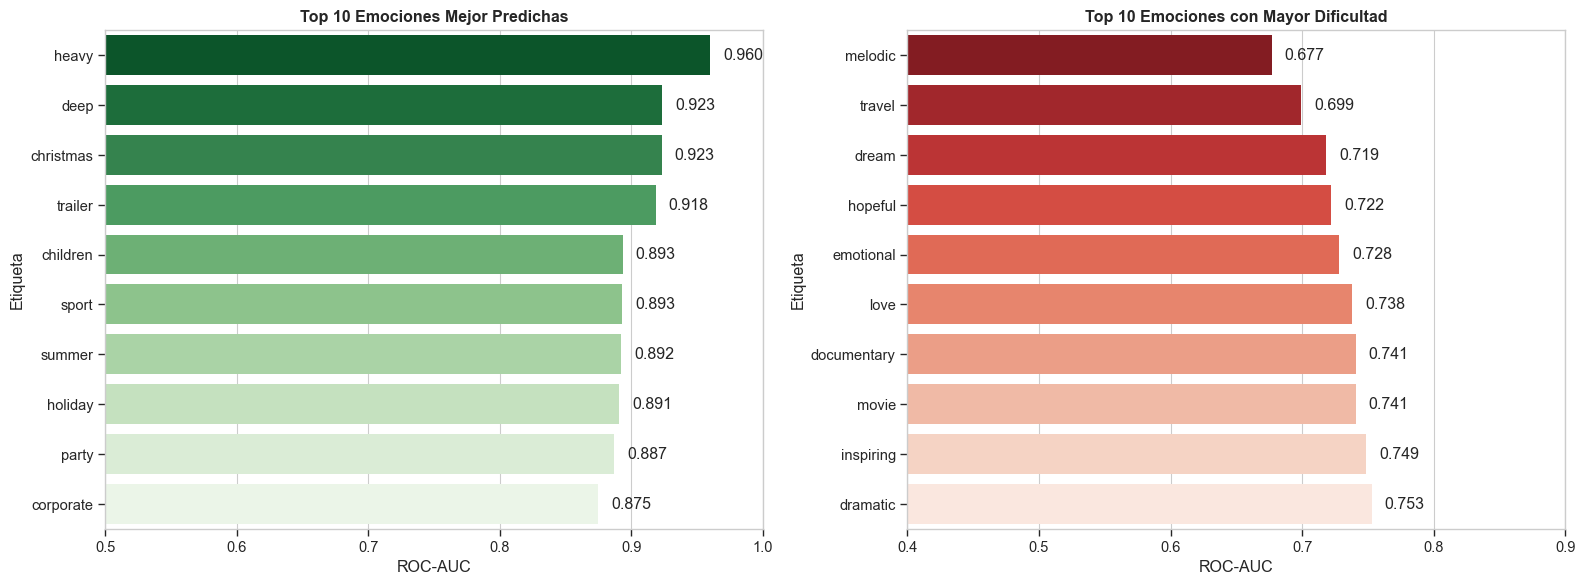

ROC-AUC Macro Promedio Calculado: 0.8129


In [7]:
# CELDA 4: Analisis de ROC-AUC por Etiqueta Individual
auc_per_class = {}

for i, label in enumerate(etiquetas_jamendo):
    # Solo calculamos si hay ejemplos positivos y negativos de esta clase en validacion
    if len(np.unique(y_true[:, i])) > 1:
        auc = roc_auc_score(y_true[:, i], y_score[:, i])
        auc_per_class[label] = auc

# Convertir a DataFrame y ordenar
df_auc = pd.DataFrame.from_dict(auc_per_class, orient='index', columns=['ROC-AUC']).reset_index()
df_auc.rename(columns={'index': 'Etiqueta'}, inplace=True)
df_auc = df_auc.sort_values(by='ROC-AUC', ascending=False)

# Visualizacion: Top 10 Mejores y Top 10 Peores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Mejores
sns.barplot(data=df_auc.head(10), x='ROC-AUC', y='Etiqueta', ax=ax1, palette='Greens_r')
ax1.set_title('Top 10 Emociones Mejor Predichas', fontweight='bold')
ax1.set_xlim(0.5, 1.0)
for i, v in enumerate(df_auc.head(10)['ROC-AUC']):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center')

# Top 10 Peores
sns.barplot(data=df_auc.tail(10).sort_values(by='ROC-AUC', ascending=True), 
            x='ROC-AUC', y='Etiqueta', ax=ax2, palette='Reds_r')
ax2.set_title('Top 10 Emociones con Mayor Dificultad', fontweight='bold')
ax2.set_xlim(0.4, 0.9)
for i, v in enumerate(df_auc.tail(10).sort_values(by='ROC-AUC', ascending=True)['ROC-AUC']):
    ax2.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig("panns_emotions_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Macro Promedio Calculado: {df_auc['ROC-AUC'].mean():.4f}")